# 41) Normal Dağılım
Normal Dağılım (Gauss Dağılımı), doğada ve gerçek hayatta en sık karşılaşılan, **çan eğrisi** şeklindeki simetrik sürekli olasılık dağılımıdır. Aslında bu sohbet boyunca defalarca dolaylı olarak kullandık (CLT'de örneklem ortalamalarının yakınsadığı şekil, Z-Score'un referans aldığı dağılım, Z-Table'ın hesapladığı olasılıklar hep bu dağılıma aitti) şimdi resmi olarak normal dağılımı tanımlıyoruz.

## Parametreler
Normal dağılımın **iki** parametresi vardır:
- **μ (mu):** Ortalama — dağılımın merkezi, tepe noktası
- **σ (sigma):** Standart sapma — dağılımın ne kadar "geniş/dar" olduğu

## Olasılık Yoğunluk Fonksiyonu (PDF)
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

Bu formülü ezberlemeye gerek yok.

## Temel Özellikler
1. **Simetriktir:** μ'nün etrafında tam simetrik, ortalama = medyan = mod
2. **Çan şeklindedir:** Tek bir tepe noktası var (μ'de), uçlara doğru simetrik olarak azalır
3. **Skewness = 0, Kurtosis = 0 (excess):** 
4. **Standart Normal Dağılım:** μ=0, σ=1 olan özel hali. Z-Score hesaplaması aslında herhangi bir normal dağılımı, bu standart hale **dönüştürme** işlemidir

## 68-95-99.7 Kuralı (Ampirik Kural)
Normal dağılımda, ortalamanın etrafındaki belirli standart sapma 
aralıklarında ne kadar veri kaldığı sabittir:
- **μ ± 1σ** → verinin yaklaşık **%68**'i
- **μ ± 2σ** → verinin yaklaşık **%95**'i
- **μ ± 3σ** → verinin yaklaşık **%99.7**'si

Bu kural, Konu 20'de öğrendiğimiz "|Z|>2 ise aykırı değer" kuralının **matematiksel temelidir** çünkü μ±2σ dışında kalan veri, sadece %5'lik bir azınlıktır, bu yüzden "nadir/sıra dışı" sayılır.

## Neden Bu Kadar Önemli?
- **CLT'nin "hedef" şeklidir:** Popülasyon ne kadar çarpık olursa olsun, örneklem ortalamaları normale yakınsar.
- Birçok doğal ve iş verisi (ölçüm hataları, IQ skorları, bazı finansal getiriler) normale yakın dağılır.
- Birçok istatistiksel test (t-testi, ANOVA, regresyon) **normallik varsayımına** dayanır, bu yüzden ileride sürekli "veri normal mi?" diye test edeceğiz.

## Normal Dağılım Her Zaman Uygun Değildir
Birçok gerçek veri seti **normal değildir**. Normal dağılım varsayımını kör körüne uygulamak yanıltıcı sonuçlara yol açabilir; bu yüzden her zaman önce veriye bakmak gerekir.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- IQ Skoru Örneği: μ=100, σ=15 ---
mu, sigma = 100, 15

# --- 68-95-99.7 Kuralını Doğrulama ---
# μ±1σ arasında kalma olasılığı (teorik olarak ~0.68 bekliyoruz)
olasilik_1sigma = stats.norm.cdf(mu + sigma, mu, sigma) - stats.norm.cdf(mu - sigma, mu, sigma)
print(f"μ±1σ ({mu-sigma} - {mu+sigma}) arası olasılık: {olasilik_1sigma:.4f}")

# μ±2σ arasında kalma olasılığı (teorik olarak ~0.95 bekliyoruz)
olasilik_2sigma = stats.norm.cdf(mu + 2*sigma, mu, sigma) - stats.norm.cdf(mu - 2*sigma, mu, sigma)
print(f"μ±2σ ({mu-2*sigma} - {mu+2*sigma}) arası olasılık: {olasilik_2sigma:.4f}")

# μ±3σ arasında kalma olasılığı (teorik olarak ~0.997 bekliyoruz)
olasilik_3sigma = stats.norm.cdf(mu + 3*sigma, mu, sigma) - stats.norm.cdf(mu - 3*sigma, mu, sigma)
print(f"μ±3σ ({mu-3*sigma} - {mu+3*sigma}) arası olasılık: {olasilik_3sigma:.4f}")

μ±1σ (85 - 115) arası olasılık: 0.6827
μ±2σ (70 - 130) arası olasılık: 0.9545
μ±3σ (55 - 145) arası olasılık: 0.9973


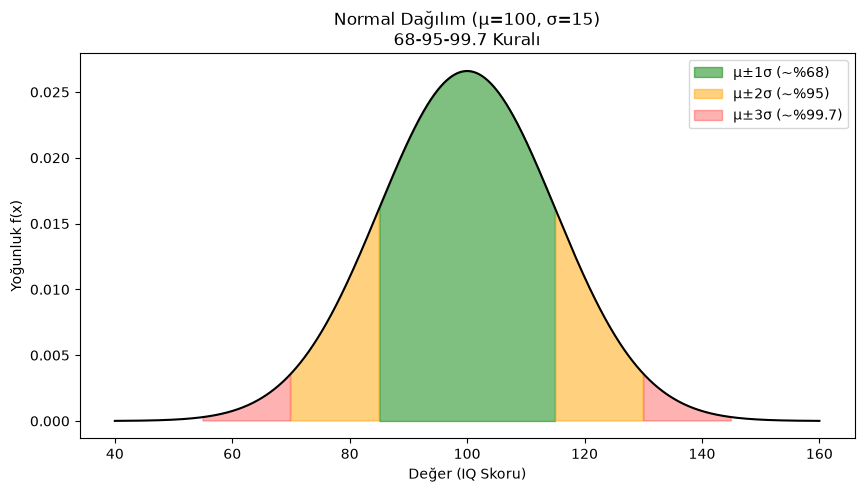

In [2]:
# --- Görselleştirme ---
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.pdf(x, mu, sigma)

plt.figure(figsize=(10,5))
plt.plot(x, y, color='black', linewidth=1.5)

# 1, 2, 3 sigma bölgelerini farklı tonlarda boyayalım
plt.fill_between(x, y, where=(x >= mu-sigma) & (x <= mu+sigma), color='green', alpha=0.5, label='μ±1σ (~%68)')
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x < mu-sigma)) | ((x > mu+sigma) & (x <= mu+2*sigma)), color='orange', alpha=0.5, label='μ±2σ (~%95)')
plt.fill_between(x, y, where=((x >= mu-3*sigma) & (x < mu-2*sigma)) | ((x > mu+2*sigma) & (x <= mu+3*sigma)), color='red', alpha=0.3, label='μ±3σ (~%99.7)')

plt.title(f"Normal Dağılım (μ={mu}, σ={sigma})\n68-95-99.7 Kuralı")
plt.xlabel("Değer (IQ Skoru)")
plt.ylabel("Yoğunluk f(x)")
plt.legend()
plt.show()

### Sonuç
Yukarıda gördüğümüz üzere normal bir dağılımda verilerin %68.27'si ortalamanın ±1 standart sapma ARALIĞINDA, verilerin %95.45'i ortalamanın ±2 standart sapma ARALIĞINDA ve verilerin %99.73'ü ortalamanın ±3 standart sapma ARALIĞINDA dağılmaktadır. Bu da teorik formülü desteklemektedir.